# Assignment 3: Euclidean and Network Distance in My Columbia-to-Hudson Routine

## Research statement

**How much longer is the shortest walk from Columbia University to familiar course-day destinations than the straight-line distance, and what does that difference reveal about how I experience the neighborhood?**

I treat the pedestrian system as a weighted graph \(G=(V,E)\). Nodes \(V\) are OpenStreetMap waypoints and intersections; edges \(E\) are pedestrian-usable street and path segments. Each edge is weighted by its length. I compare:

- **Euclidean distance:** the straight line between two personal locations.
- **Network distance:** the shortest legal route through the pedestrian graph, plus short connectors between each personal point and its matched graph node.

This notebook continues the destination-based mental map from Assignment 2. I do not live near Columbia, but I regularly visit the area for class and sometimes continue toward the Hudson River.

### Short answer

For the three reliable destination points, the pedestrian network makes the trip **about 19% to 49% longer** than a straight line. The subway has the largest percentage difference because it is very close to the origin, while West Harlem Piers has the largest absolute extra distance. Euclidean distance is useful as a baseline, but it ignores entrances, blocks, paths, and barriers that structure the actual walk.

## 1. Data and reproducibility

The personal locations come from `02_columbia_hudson_routine.geojson`, which I manually created for Assignment 2. The walking network comes from [OpenStreetMap](https://www.openstreetmap.org/) and is processed with [OSMnx](https://osmnx.readthedocs.io/).

The local GraphML file stores the downloaded network so the notebook can run without repeatedly calling the Overpass API. If that cache is missing, the code downloads the same bounding box and saves it. The custom filter includes pedestrian-usable streets, footways, and cycleways where walking is not prohibited; this matters along the Hudson River Greenway.

In [1]:
from pathlib import Path
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import networkx as nx
import numpy as np
import osmnx as ox
import pandas as pd
from shapely.geometry import LineString

warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 80)

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "content/Assignments/02_columbia_hudson_routine.geojson").exists():
        ROOT = candidate
        break
else:
    raise FileNotFoundError(
        "Open this notebook from the cdp-mapping-systems-main folder or one of its subfolders."
    )

POINTS_PATH = ROOT / "content/Assignments/02_columbia_hudson_routine.geojson"
GRAPH_PATH = ROOT / "content/Assignments/data/columbia_hudson_walk.graphml"

print(f"Project root: {ROOT}")
print(f"Personal points: {POINTS_PATH.name}")
print(f"Network cache: {GRAPH_PATH.name}")

Project root: repository root
Personal points: 02_columbia_hudson_routine.geojson
Network cache: columbia_hudson_walk.graphml


## 2. Create the pedestrian network

The study area is a bounding box around Morningside Heights, Riverside Park, and West Harlem. I use a directed `MultiDiGraph`: a pair of nodes can have more than one connecting edge, and direction can represent movement restrictions.

For every route, NetworkX minimizes:

\[
d_N(s,t)=\min_{p \in P(s,t)} \sum_{e \in p}\text{length}(e)
\]

where \(P(s,t)\) is the set of available network paths from origin \(s\) to destination \(t\).

In [2]:
ox.settings.use_cache = True
ox.settings.log_console = False

# (left, bottom, right, top) in longitude/latitude.
BBOX = (-73.981, 40.798, -73.953, 40.825)

# Include pedestrian-usable highways and paths, including cycleways where foot access
# is not prohibited. The graph is not simplified so long paths retain more OSM nodes.
PEDESTRIAN_FILTER = (
    '["highway"]["area"!~"yes"]["access"!~"private"]'
    '["highway"!~"abandoned|bus_guideway|construction|motor|no|planned|'
    'platform|proposed|raceway|razed|rest_area|services"]'
    '["foot"!~"no"]["service"!~"private"]'
)

if GRAPH_PATH.exists():
    G = ox.load_graphml(GRAPH_PATH)
    graph_source = "local GraphML cache"
else:
    G = ox.graph_from_bbox(
        bbox=BBOX,
        network_type="walk",
        custom_filter=PEDESTRIAN_FILTER,
        simplify=False,
        retain_all=False,
    )
    GRAPH_PATH.parent.mkdir(parents=True, exist_ok=True)
    ox.save_graphml(G, filepath=GRAPH_PATH)
    graph_source = "new OpenStreetMap download"

graph_summary = pd.DataFrame(
    {
        "Measure": ["Source", "Graph type", "Nodes", "Directed edges", "CRS"],
        "Value": [
            graph_source,
            type(G).__name__,
            f"{G.number_of_nodes():,}",
            f"{G.number_of_edges():,}",
            G.graph.get("crs"),
        ],
    }
)
graph_summary

,Measure,Value
0,Source,local GraphML cache
1,Graph type,MultiDiGraph
2,Nodes,"8,347"
3,Directed edges,"20,622"
4,CRS,epsg:4326


## 3. Select and match the personal nodes

The Columbia campus point is the origin. I measure routes to three destinations:

1. 116 St-Columbia University subway
2. Hungarian Pastry Shop
3. West Harlem Piers Park

I selected these three because each personal point falls within 25 meters of a graph node. The two approximate Cherry Walk / Riverside points remain visible as contextual mental-map anchors, but I exclude them from the distance table. They lie in the middle of a long mapped path edge; forcing them to the nearest endpoint would add hundreds of meters that are an artifact of graph representation rather than experienced walking. This is a data-quality decision, not evidence that those places are inaccessible.

In [3]:
all_points = gpd.read_file(POINTS_PATH).sort_values("sequence")
measured_sequences = [1, 2, 3, 6]
measured = all_points[all_points["sequence"].isin(measured_sequences)].copy()

matched_nodes, snap_distances = ox.distance.nearest_nodes(
    G,
    X=measured.geometry.x.to_numpy(),
    Y=measured.geometry.y.to_numpy(),
    return_dist=True,
)
measured["network_node"] = matched_nodes
measured["snap_distance_m"] = snap_distances

short_names = {
    1: "Columbia campus",
    2: "116 St subway",
    3: "Hungarian Pastry Shop",
    6: "West Harlem Piers",
}
measured["short_name"] = measured["sequence"].map(short_names)

measured[
    ["sequence", "short_name", "category", "network_node", "snap_distance_m"]
].round({"snap_distance_m": 1})

,sequence,short_name,category,network_node,snap_distance_m
0,1,Columbia campus,class,8375689212,1.1
1,2,116 St subway,transit,9452317499,12.9
2,3,Hungarian Pastry Shop,coffee and study,6814262784,13.3
5,6,West Harlem Piers,waterfront destination,7616666777,21.2


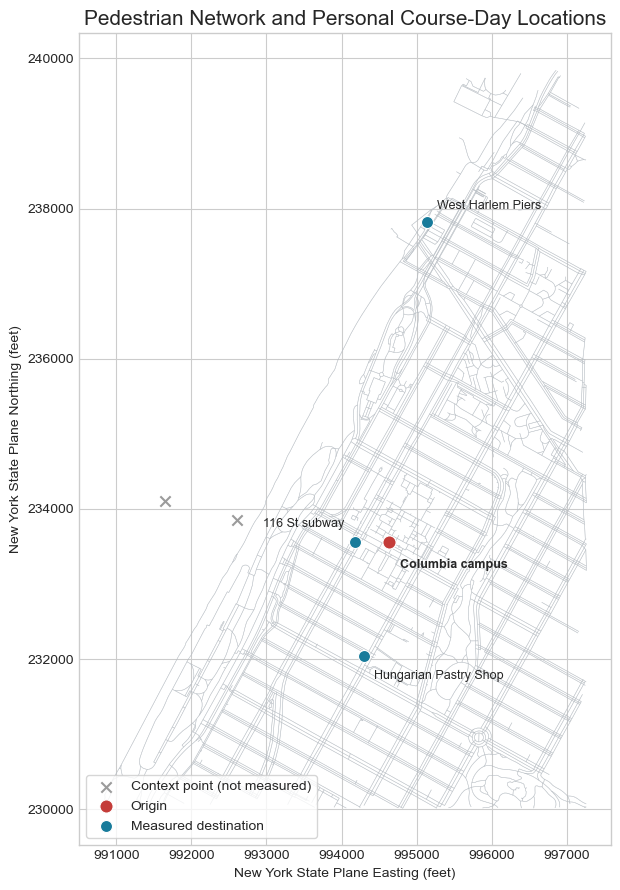

In [4]:
nodes_gdf, edges_gdf = ox.graph_to_gdfs(G)
map_crs = "EPSG:2263"
edges_map = edges_gdf.to_crs(map_crs)
all_points_map = all_points.to_crs(map_crs)
measured_map = measured.to_crs(map_crs)

fig, ax = plt.subplots(figsize=(11, 9))
edges_map.plot(ax=ax, color="#b8bec4", linewidth=0.35, alpha=0.75)

context_points = all_points_map[
    ~all_points_map["sequence"].isin(measured_sequences)
]
context_points.plot(
    ax=ax,
    color="#9b9b9b",
    marker="x",
    markersize=55,
    linewidth=1.5,
    label="Context point (not measured)",
)

measured_map[measured_map["sequence"] == 1].plot(
    ax=ax,
    color="#c43c39",
    edgecolor="white",
    linewidth=0.8,
    markersize=90,
    zorder=4,
    label="Origin",
)
measured_map[measured_map["sequence"] != 1].plot(
    ax=ax,
    color="#187b9b",
    edgecolor="white",
    linewidth=0.8,
    markersize=75,
    zorder=4,
    label="Measured destination",
)

label_styles = {
    1: {"xytext": (8, -12), "ha": "left", "va": "top"},
    2: {"xytext": (-8, 9), "ha": "right", "va": "bottom"},
    3: {"xytext": (7, -10), "ha": "left", "va": "top"},
    6: {"xytext": (7, 7), "ha": "left", "va": "bottom"},
}
for _, row in measured_map.iterrows():
    style = label_styles[row["sequence"]]
    ax.annotate(
        row["short_name"],
        (row.geometry.x, row.geometry.y),
        xytext=style["xytext"],
        textcoords="offset points",
        ha=style["ha"],
        va=style["va"],
        fontsize=9,
        weight="bold" if row["sequence"] == 1 else "normal",
    )

ax.set_title("Pedestrian Network and Personal Course-Day Locations", fontsize=15)
ax.set_xlabel("New York State Plane Easting (feet)")
ax.set_ylabel("New York State Plane Northing (feet)")
ax.legend(loc="lower left", frameon=True)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 4. Calculate Euclidean and shortest-path distances

I project the personal points to `EPSG:2263`, a New York State Plane coordinate system whose units are feet, before calculating straight-line distance:

\[
d_E=\sqrt{(x_2-x_1)^2+(y_2-y_1)^2}
\]

For network distance, I use Dijkstra's shortest-path algorithm with OSM edge length as the weight. I also add the small straight connector from each personal point to its matched graph node. This keeps the start and end locations consistent across the two measures.

Walking time is an estimate at 3 miles per hour. It excludes waiting, stairs, elevation, crowds, weather, and indoor movement.

In [5]:
METERS_PER_MILE = 1609.344
FEET_PER_MILE = 5280
WALKING_SPEED_MPH = 3

measured_projected = measured.to_crs(map_crs)
origin_index = measured.index[measured["sequence"] == 1][0]
origin = measured.loc[origin_index]
origin_projected = measured_projected.loc[origin_index]
origin_node = origin["network_node"]

routes = {}
records = []

for destination_index, destination in measured[measured["sequence"] != 1].iterrows():
    destination_projected = measured_projected.loc[destination_index]
    destination_node = destination["network_node"]

    euclidean_miles = (
        origin_projected.geometry.distance(destination_projected.geometry)
        / FEET_PER_MILE
    )

    route = nx.shortest_path(
        G, source=origin_node, target=destination_node, weight="length"
    )
    route_edges = ox.routing.route_to_gdf(G, route, weight="length")
    route_edge_meters = route_edges["length"].sum()
    connector_meters = (
        origin["snap_distance_m"] + destination["snap_distance_m"]
    )
    network_miles = (route_edge_meters + connector_meters) / METERS_PER_MILE

    routes[destination["sequence"]] = {
        "nodes": route,
        "edges": route_edges,
    }
    records.append(
        {
            "sequence": destination["sequence"],
            "destination": destination["short_name"],
            "euclidean_miles": euclidean_miles,
            "network_miles": network_miles,
            "extra_miles": network_miles - euclidean_miles,
            "detour_ratio": network_miles / euclidean_miles,
            "percent_longer": (network_miles / euclidean_miles - 1) * 100,
            "estimated_minutes": network_miles / WALKING_SPEED_MPH * 60,
        }
    )

results = pd.DataFrame(records).sort_values("sequence").reset_index(drop=True)
results_display = results[
    [
        "destination",
        "euclidean_miles",
        "network_miles",
        "extra_miles",
        "percent_longer",
        "estimated_minutes",
    ]
].copy()
results_display.columns = [
    "Destination",
    "Euclidean (mi)",
    "Network (mi)",
    "Extra (mi)",
    "Network longer (%)",
    "Walk time (min)",
]
results_display.round(3)

,Destination,Euclidean (mi),Network (mi),Extra (mi),Network longer (%),Walk time (min)
0,116 St subway,0.085,0.127,0.042,49.198,2.535
1,Hungarian Pastry Shop,0.296,0.375,0.080,26.938,7.508
2,West Harlem Piers,0.813,0.964,0.151,18.595,19.275


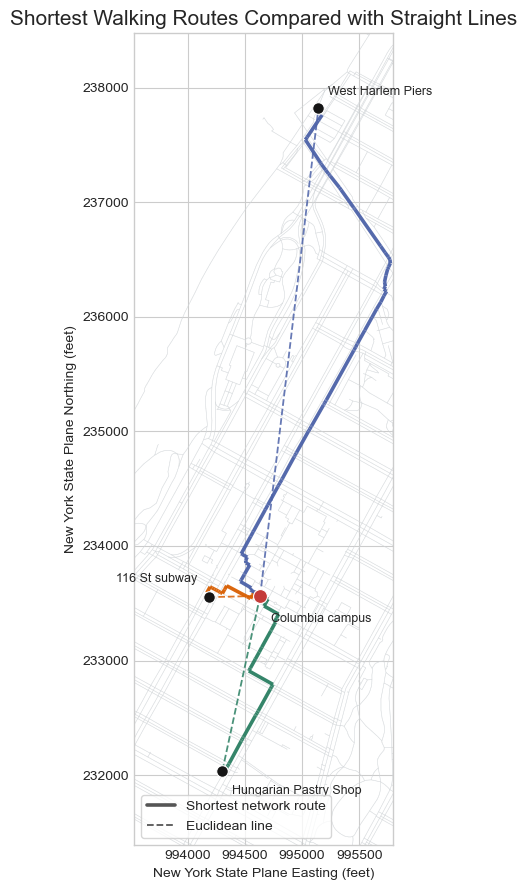

In [6]:
route_colors = {
    2: "#d95f02",
    3: "#2a7f62",
    6: "#4c62a8",
}

fig, ax = plt.subplots(figsize=(11, 9))
edges_map.plot(ax=ax, color="#d3d7da", linewidth=0.35, alpha=0.65)

origin_geom = origin.geometry
for _, destination in measured[measured["sequence"] != 1].iterrows():
    sequence = destination["sequence"]
    color = route_colors[sequence]

    route_map = routes[sequence]["edges"].to_crs(map_crs)
    route_map.plot(ax=ax, color=color, linewidth=2.6, alpha=0.95)

    direct_line = gpd.GeoSeries(
        [LineString([origin_geom, destination.geometry])],
        crs=measured.crs,
    ).to_crs(map_crs)
    direct_line.plot(
        ax=ax,
        color=color,
        linewidth=1.3,
        linestyle="--",
        alpha=0.85,
    )

measured_map[measured_map["sequence"] == 1].plot(
    ax=ax,
    color="#c43c39",
    edgecolor="white",
    linewidth=0.8,
    markersize=100,
    zorder=5,
)
measured_map[measured_map["sequence"] != 1].plot(
    ax=ax,
    color="#151515",
    edgecolor="white",
    linewidth=0.8,
    markersize=70,
    zorder=5,
)

for _, row in measured_map.iterrows():
    style = label_styles[row["sequence"]]
    ax.annotate(
        row["short_name"],
        (row.geometry.x, row.geometry.y),
        xytext=style["xytext"],
        textcoords="offset points",
        ha=style["ha"],
        va=style["va"],
        fontsize=9,
    )

handles = [
    Line2D([0], [0], color="#555555", linewidth=2.6, label="Shortest network route"),
    Line2D(
        [0], [0], color="#555555", linewidth=1.3, linestyle="--",
        label="Euclidean line"
    ),
]
ax.legend(handles=handles, loc="lower left", frameon=True)
ax.set_title("Shortest Walking Routes Compared with Straight Lines", fontsize=15)
ax.set_xlabel("New York State Plane Easting (feet)")
ax.set_ylabel("New York State Plane Northing (feet)")
ax.set_aspect("equal")

minx, miny, maxx, maxy = measured_map.total_bounds
ax.set_xlim(minx - 650, maxx + 650)
ax.set_ylim(miny - 650, maxy + 650)
plt.tight_layout()
plt.show()

The solid colored lines follow the shortest available network route. The dashed lines pass directly through blocks, buildings, and other obstacles. Their visual separation is the spatial form of the distance difference.

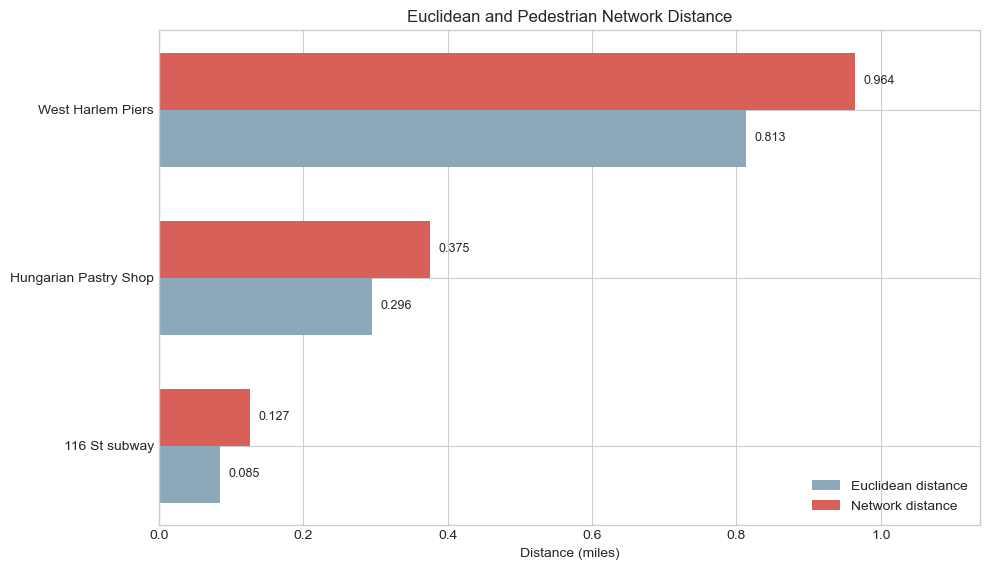

In [7]:
plot_data = results.sort_values("network_miles", ascending=True)
y = np.arange(len(plot_data))
height = 0.34

fig, ax = plt.subplots(figsize=(10, 5.8))
ax.barh(
    y - height / 2,
    plot_data["euclidean_miles"],
    height,
    color="#8da9b9",
    label="Euclidean distance",
)
ax.barh(
    y + height / 2,
    plot_data["network_miles"],
    height,
    color="#d95f59",
    label="Network distance",
)

for position, (_, row) in enumerate(plot_data.iterrows()):
    ax.text(
        row["euclidean_miles"] + 0.012,
        position - height / 2,
        f'{row["euclidean_miles"]:.3f}',
        va="center",
        fontsize=9,
    )
    ax.text(
        row["network_miles"] + 0.012,
        position + height / 2,
        f'{row["network_miles"]:.3f}',
        va="center",
        fontsize=9,
    )

ax.set_yticks(y, plot_data["destination"])
ax.set_xlabel("Distance (miles)")
ax.set_title("Euclidean and Pedestrian Network Distance")
ax.legend(loc="lower right")
ax.set_xlim(0, plot_data["network_miles"].max() * 1.18)
plt.tight_layout()
plt.show()

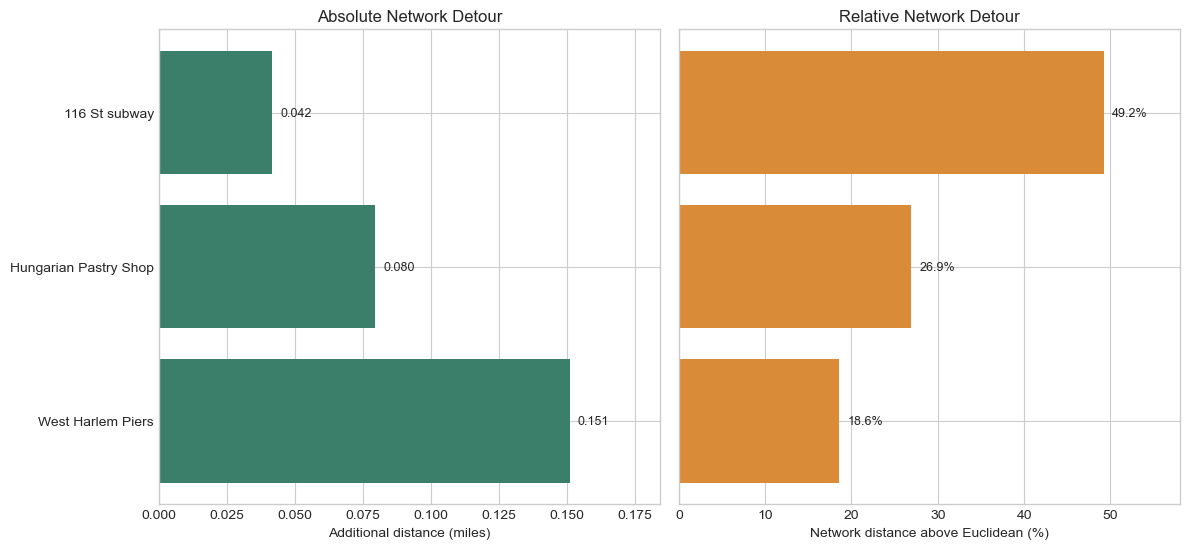

In [8]:
plot_data = results.sort_values("percent_longer", ascending=True)
y = np.arange(len(plot_data))

fig, axes = plt.subplots(1, 2, figsize=(12, 5.6), sharey=True)

axes[0].barh(y, plot_data["extra_miles"], color="#3b7f6b")
axes[0].set_yticks(y, plot_data["destination"])
axes[0].set_xlabel("Additional distance (miles)")
axes[0].set_title("Absolute Network Detour")
for position, value in enumerate(plot_data["extra_miles"]):
    axes[0].text(value + 0.003, position, f"{value:.3f}", va="center", fontsize=9)

axes[1].barh(y, plot_data["percent_longer"], color="#d98b37")
axes[1].set_xlabel("Network distance above Euclidean (%)")
axes[1].set_title("Relative Network Detour")
for position, value in enumerate(plot_data["percent_longer"]):
    axes[1].text(value + 1, position, f"{value:.1f}%", va="center", fontsize=9)

axes[0].set_xlim(0, plot_data["extra_miles"].max() * 1.22)
axes[1].set_xlim(0, plot_data["percent_longer"].max() * 1.18)
plt.tight_layout()
plt.show()

## 5. Findings

- **116 St subway:** 0.085 miles in a straight line and 0.127 miles on the network. The route is **49.2% longer**, but the absolute difference is only 0.042 miles. A percentage can look dramatic when the baseline trip is very short.
- **Hungarian Pastry Shop:** 0.296 straight-line miles and 0.375 network miles, a **26.9%** increase.
- **West Harlem Piers:** 0.813 straight-line miles and 0.964 network miles. Its percentage increase is the smallest (**18.6%**), but it has the largest absolute extra distance (0.151 miles).

The rankings depend on the metric. The subway has the highest *relative* detour, while the piers have the highest *absolute* detour. This is why both a distance chart and a percentage chart are necessary.

## 6. Reflection: mathematical distance versus experience

Euclidean distance answers a useful but limited question: how far apart are two coordinates? It treats the city as a flat, empty plane. In experience, I cannot walk through buildings, across every campus boundary, or directly through infrastructure. The network measure better represents the sequence of streets, paths, and entrances available to a pedestrian.

Even network distance is not the same as experienced distance. The shortest route may not be the route I prefer. A quieter walk, a familiar entrance, a river view, a steep slope, a signal wait, darkness, crowding, weather, or construction can change how long and how difficult the trip feels. The network also depends on OpenStreetMap completeness and on my approximate mental-map points.

The water-related destination makes this especially visible. West Harlem Piers belongs to the same mental course-day landscape as Columbia, but reaching the waterfront is structured by a limited set of connected paths rather than by its apparent closeness on a map.

## 7. What these measures can and cannot tell us

**They can tell us:**

- the shortest modeled walking distance through a defined graph;
- the extra distance created by the spatial arrangement of that graph;
- which result changes when we compare absolute and relative difference.

**They cannot tell us:**

- the exact route I actually chose on a particular day;
- travel time without assumptions about speed and delays;
- comfort, safety, accessibility, slope, weather, or scenic preference;
- whether every OSM path or entrance was complete and open at the time of travel.

## 8. Presentation summary

1. I defined the pedestrian system as a weighted OpenStreetMap graph.
2. I measured from Columbia campus to three familiar course-day destinations.
3. I compared straight-line distance with shortest-path distance.
4. All network trips were longer, but the biggest percentage detour was not the biggest absolute detour.
5. The main conclusion is that geometric closeness and experienced accessibility are related, but they are not the same.